In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import warnings; warnings.simplefilter('ignore')
import sys
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_models

import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
from orbit import orbit
import cosmo as co

from scipy.integrate import quad
from scipy.optimize import root_scalar
import astropy.coordinates as crd
import astropy.units as u


In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [4]:
early = jsm_visualize.Tree_Vis(file="../../../StellarHalo/data/four_examples/DF/early_evo.npz", merger_crit=-2, fesc=0.2, scatter=False, verbose=False)
middle = jsm_visualize.Tree_Vis(file="../../../StellarHalo/data/four_examples/DF/middle_evo.npz", merger_crit=-2, fesc=0.2, scatter=False, verbose=False)
late = jsm_visualize.Tree_Vis(file="../../../StellarHalo/data/four_examples/DF/late_evo.npz", merger_crit=-2, fesc=0.2, scatter=False, verbose=False)
latest = jsm_visualize.Tree_Vis(file="../../../StellarHalo/data/four_examples/DF/latest_evo.npz", merger_crit=-2, fesc=0.2, scatter=False, verbose=False)

In [5]:
def plot_host_potential(tree, tree_title):

    z0 = tree.host_profiles[0]
    radii = np.logspace(-2, np.log10(3*z0.rh), 20)

    norm = colors.Normalize(
        vmin=np.log10(1 + tree.redshift.min()),
        vmax=np.log10(1 + tree.redshift.max())
    )
    colormap = cm.viridis

    fig, ax = plt.subplots(
        3, 1,
        figsize=(8, 7),
        sharex=True,
        constrained_layout=True
    )

    for time_index, profile in enumerate(tree.host_profiles):

        zval = np.log10(1 + tree.redshift[time_index])
        cc = colormap(norm(zval))

        # Density
        ax[0].loglog(radii, profile.rho(radii), color=cc, alpha=0.3, lw=1)
        ax[0].axvline(profile.rmax, color=cc, lw=0.1)

        # Enclosed Mass
        ax[1].loglog(radii, profile.M(radii), color=cc, alpha=0.3, lw=1)
        ax[1].axvline(profile.rmax, color=cc, lw=0.1)

        # Circular Velocity
        ax[2].loglog(radii, profile.Vcirc(radii), color=cc, alpha=0.3, lw=1)
        ax[2].axvline(profile.rmax, color=cc, lw=0.1)

    # Highlight z=0
    ax[0].loglog(radii, z0.rho(radii), color="darkred", lw=3, label="NFW (z=0)")
    ax[1].loglog(radii, z0.M(radii), color="darkred", lw=3)
    ax[2].loglog(radii, z0.Vcirc(radii), color="darkred", lw=3)

    ax[0].axvline(z0.rmax, color="darkred", lw=3, ls="--")
    ax[1].axvline(z0.rmax, color="darkred", lw=3, ls="--")
    ax[2].axvline(z0.rmax, color="darkred", lw=3, ls="--")

    ax[0].legend(loc=3)

    # Labels
    ax[0].set_ylabel("$\\rho$ [M$_{\\odot}$ / kpc$^3$]")
    ax[1].set_ylabel("M$_{\\mathrm{enc}}$ [M$_{\\odot}$]")
    ax[2].set_ylabel("V$_{\\mathrm{circ}}$ [km / s]")
    ax[2].set_xlabel("R [kpc]")

    # Limits
    ax[0].set_ylim(1e2, 1e10)
    ax[1].set_ylim(1e6, 2e12)
    ax[2].set_ylim(1e1, 200)

    ax[2].set_xlim(1e-1, 300)

    sm = cm.ScalarMappable(cmap=colormap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        orientation="vertical",
        fraction=0.025,   # thinner than default (~0.05)
        pad=0.02
    )
    cbar.set_label("log (1 + z)")

    ax[0].set_title(tree_title)
    plt.show()

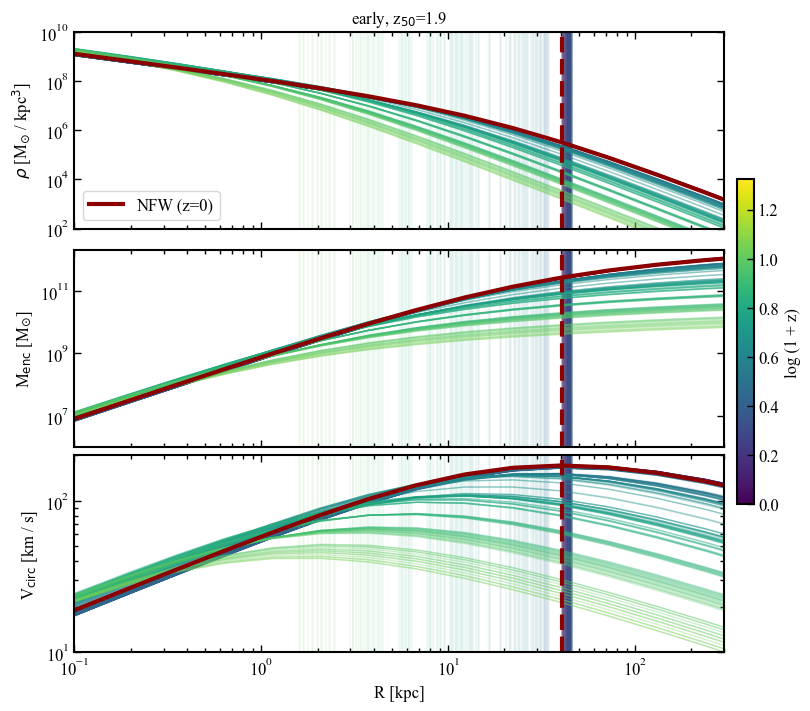

In [6]:
plot_host_potential(early, f"early, z$_{{50}}$={early.host_z50:.2g}")

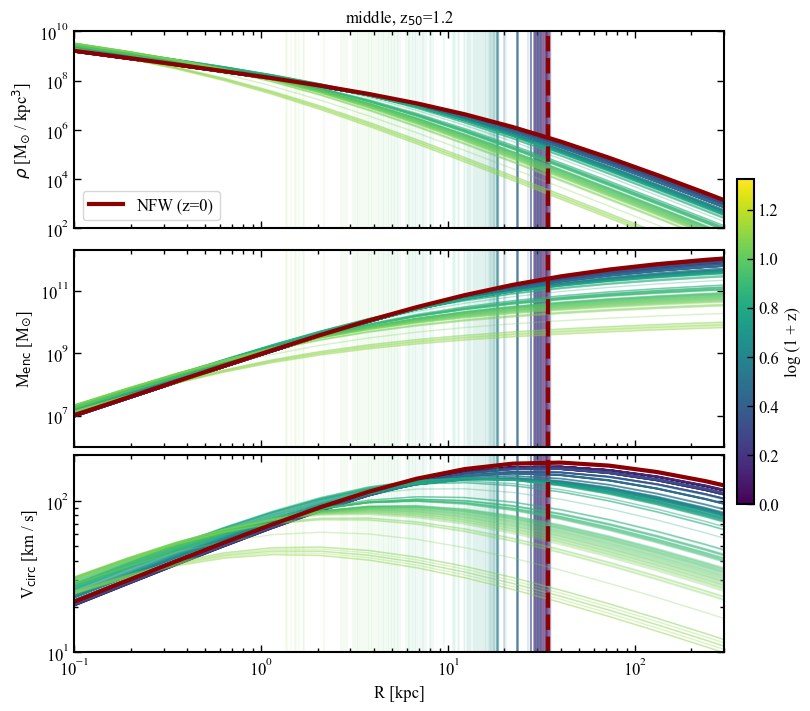

In [7]:
plot_host_potential(middle, f"middle, z$_{{50}}$={middle.host_z50:.2g}")

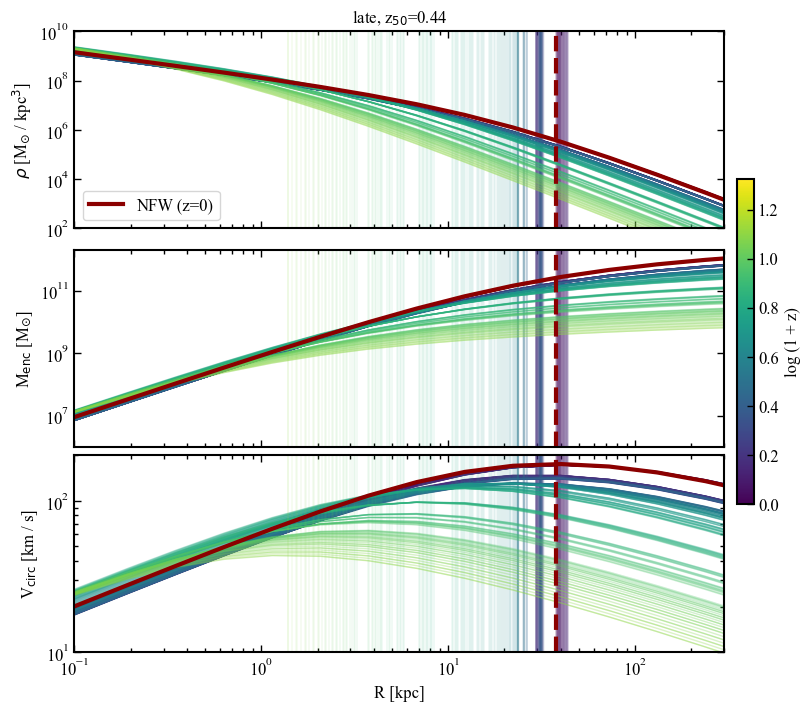

In [8]:
plot_host_potential(late, f"late, z$_{{50}}$={late.host_z50:.2g}")

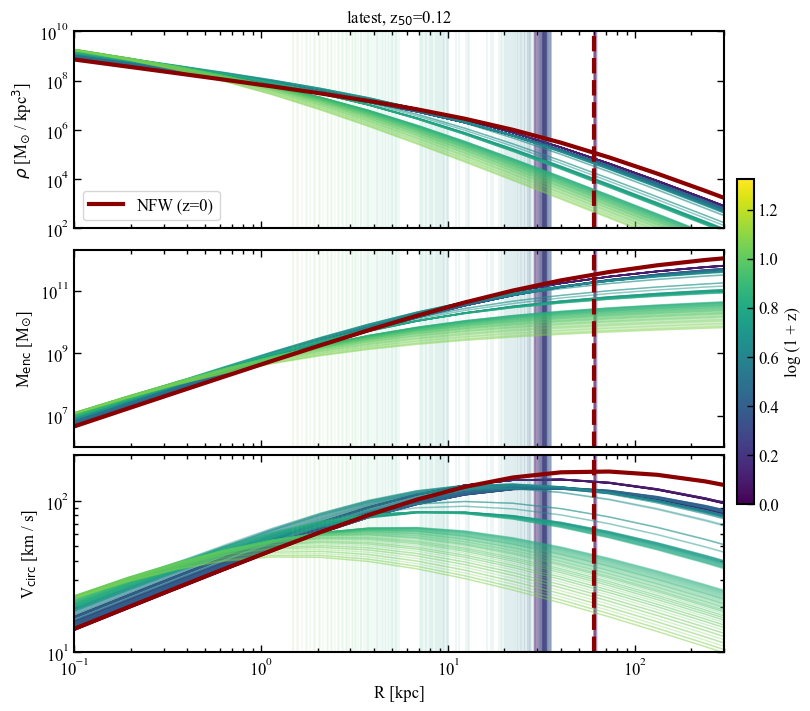

In [9]:
plot_host_potential(latest, f"latest, z$_{{50}}$={latest.host_z50:.2g}")